In [1]:
#Importing the Libraries
!pip install scikit-learn==1.2.2
import pandas as pd
import numpy as np
import keras
from matplotlib import pyplot as plt

In [2]:
# Uploading and exploring the dataset
dataset = pd.read_csv('creditcard.csv')
dataset.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [3]:
len(dataset)

284807

In [4]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [5]:
dataset['Class'].value_counts()

,count
Class,
0,284315
1,492


In [6]:
dataset.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


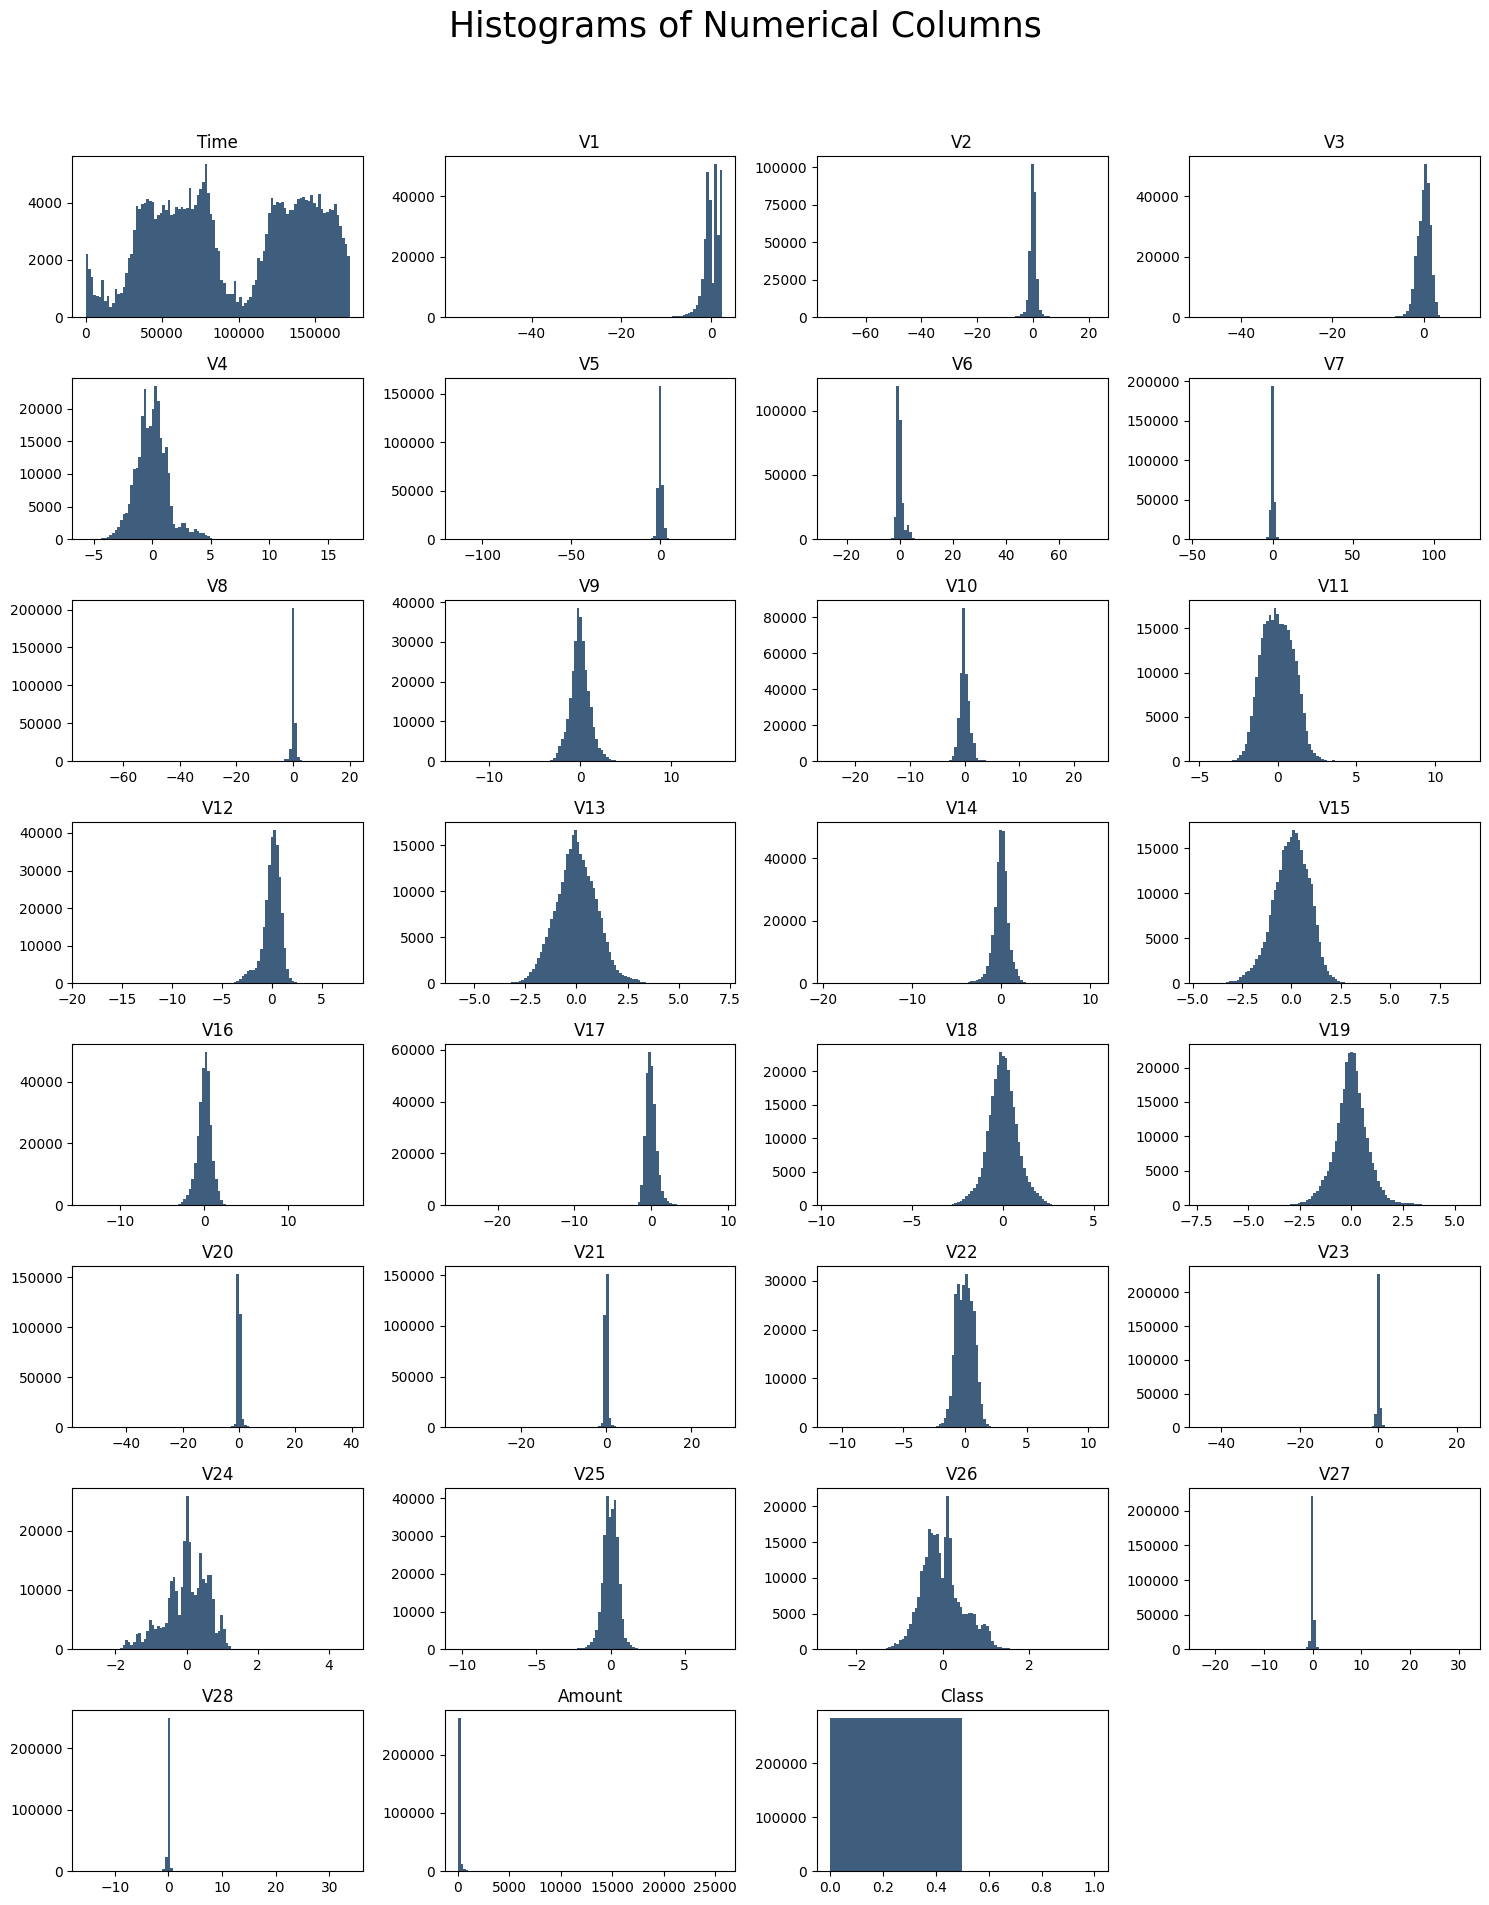

In [7]:
#Using histograms to represent the columns
fig = plt.figure(figsize=(15, 20))
plt.suptitle('Histograms of Numerical Columns', fontsize=25)
for i in range(dataset.shape[1]):
    plt.subplot(8, 4, i + 1)
    f = plt.gca()
    f.set_title(dataset.columns.values[i])
    vals = np.size(dataset.iloc[:, i].unique())
    if vals >= 100:
        vals = 100                                    # limiting bins to 100
    plt.hist(dataset.iloc[:, i], bins=vals, color='#3F5D7D')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])

In [8]:
#DATA PREPROCESSING
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
dataset['Amount_Normalize'] = sc.fit_transform(dataset['Amount'].values.reshape(-1,1))
dataset.drop(['Time', 'Amount'], axis=1, inplace=True)
dataset.head()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V21,V22,V23,V24,V25,V26,V27,V28,Class,Amount_Normalize
0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,0,0.244964
1,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,0,-0.342475
2,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,0,1.160686
3,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,0,0.140534
4,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,0,-0.073403


In [9]:
x = dataset.iloc[:, dataset.columns != 'Class']
y = dataset.iloc[:, dataset.columns == 'Class'] # to determine if fraud or not

In [10]:
y.head()

,Class
0,0
1,0
2,0
3,0
4,0


In [11]:
#train and test split the data
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test =train_test_split(x, y, test_size=0.3, random_state=0)

In [12]:
# Import SMOTE
from imblearn.over_sampling import SMOTE

# Apply SMOTE for oversampling
smote = SMOTE(random_state=0)
x_train_resampled, y_train_resampled = smote.fit_resample(x_train, y_train)

In [13]:
x_train.shape

(199364, 29)

In [14]:
x_test.shape

(85443, 29)

# **LOGISTIC REGRESSION**





In [42]:
from sklearn.linear_model import LogisticRegression

# Split the data into training and testing sets
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=0)

# Create a Logistic Regression model
model = LogisticRegression()
model.fit(x_train_resampled, y_train_resampled)


/usr/local/lib/python3.10/dist-packages/sklearn/utils/validation.py:1143: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


LogisticRegression()

Accuracy of the LogisticRegression: 0.975270063082991
Precision of the LogisticRegression : 0.06037567084078712
Recall of the LogisticRegression: 0.9183673469387755
F1 score of the LogisticRegression: 0.11330255979857323
Confusion Matrix:
[[83195  2101]
 [   12   135]]


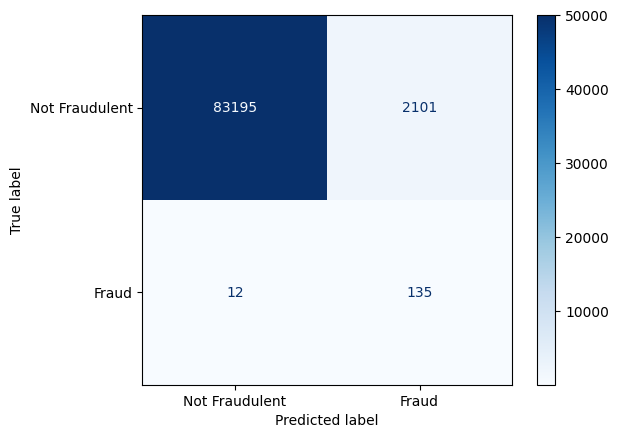

In [43]:
# Make predictions on the test set
y_pred = model.predict(x_test)

#Evaluation of metrics
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay

# Create and display the confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Fraudulent', 'Fraud'])
disp.plot(cmap=plt.cm.Blues, values_format='d')
disp.im_.set_clim(vmax=50000)

# preformance metrics of model
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
print("Accuracy of the LogisticRegression:", acc)
print("Precision of the LogisticRegression :", prec)
print("Recall of the LogisticRegression:", rec)
print("F1 score of the LogisticRegression:", f1)

print("Confusion Matrix:")
print(cm)

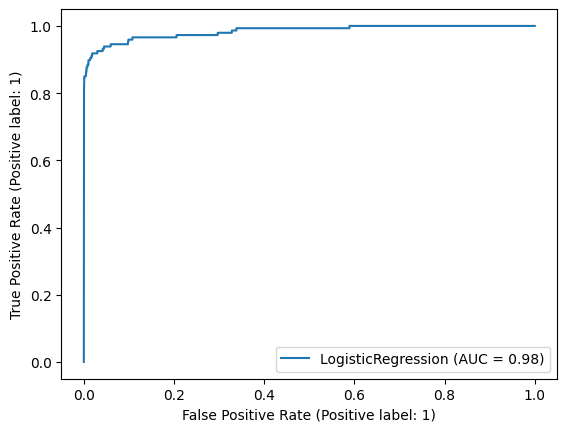

In [44]:
# Plot the ROC curve
roc_display = RocCurveDisplay.from_estimator(model, x_test, y_test)
plt.show()

Confusion Matrix:
[[277159   7156]
 [    40    452]]


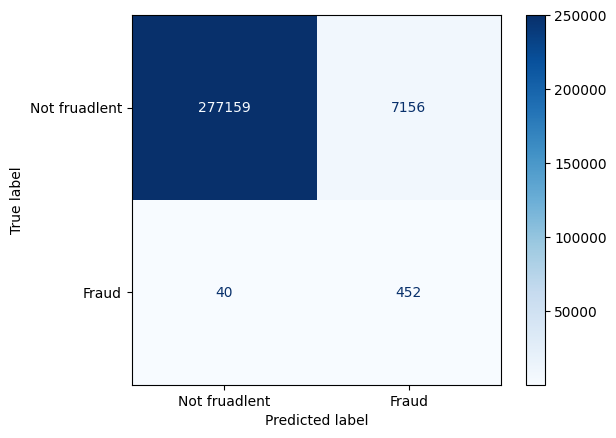

In [45]:
#confusion matrix for whole dataset
y_pred = model.predict(x)
conf_matrix = confusion_matrix(y, y_pred.round())
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=['Not fruadlent','Fraud'])
disp.plot(cmap=plt.cm.Blues, values_format='d')
disp.im_.set_clim(vmax=250000)

print("Confusion Matrix:")
print(conf_matrix)

plt.show()


# **RANDOM FOREST**



In [21]:
from sklearn.ensemble import RandomForestClassifier
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=0)
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=0)
# Train the model
rf_classifier.fit(x_train_resampled, y_train_resampled)

<ipython-input-21-07c6d8f167f8>:5: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  rf_classifier.fit(x_train_resampled, y_train_resampled)


RandomForestClassifier(random_state=0)

Accuracy of Random Forest: 0.9995084442259752
Precision of Random Forest: 0.9007633587786259
Recall of the Random Forest: 0.8027210884353742
F1 score of the Random Forest: 0.8489208633093525
Confusion Matrix:
[[85283    13]
 [   29   118]]


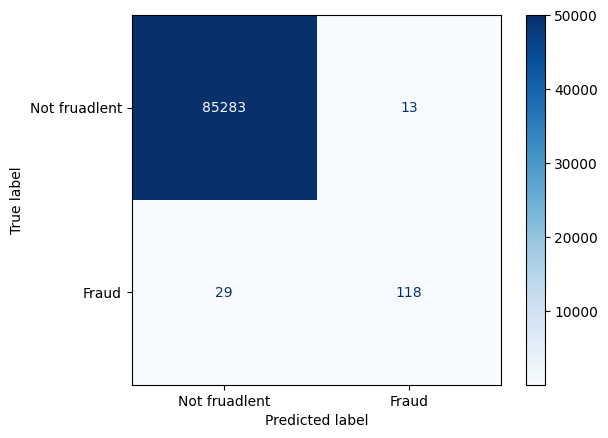

In [22]:
y_pred = rf_classifier.predict(x_test)
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay # Import RocCurveDisplay instead of plot_roc_curve

conf_matrix = confusion_matrix(y_test, y_pred.round())
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=['Not fruadlent','Fraud'])
disp.plot(cmap=plt.cm.Blues, values_format='d')
disp.im_.set_clim(vmax=50000)

# Evaluate the model
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
print("Accuracy of Random Forest:", acc)
print("Precision of Random Forest:", prec)
print("Recall of the Random Forest:", rec)
print("F1 score of the Random Forest:", f1)

print("Confusion Matrix:")
print(conf_matrix)

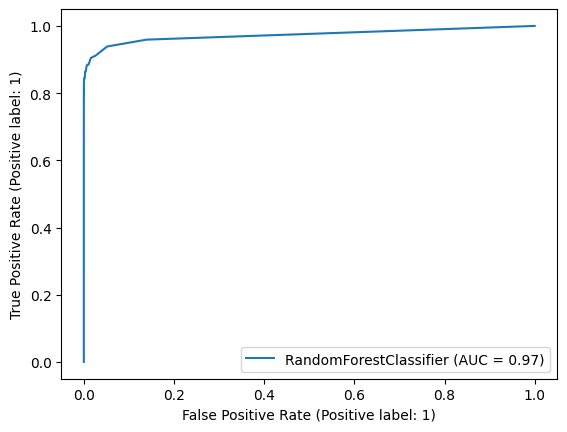

In [23]:
roc_display = RocCurveDisplay.from_estimator(rf_classifier, x_test, y_test)
plt.show()

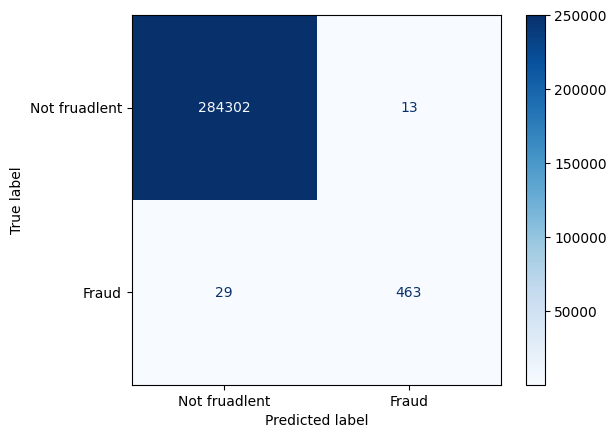

In [24]:
y_pred = rf_classifier.predict(x)
conf_matrix = confusion_matrix(y, y_pred.round())
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=['Not fruadlent','Fraud'])
disp.plot(cmap=plt.cm.Blues, values_format='d')
disp.im_.set_clim(vmax=250000)
plt.show()

# **DECISION TREES**

In [25]:
from sklearn.tree import DecisionTreeClassifier
classifier = DecisionTreeClassifier(criterion = 'entropy', random_state = 0)
classifier.fit(x_train_resampled, y_train_resampled)

DecisionTreeClassifier(criterion='entropy', random_state=0)

Accuracy of the Decision tree: 0.9981157028662383
Precision of the Decision tree: 0.4713114754098361
Recall of the Decision tree: 0.782312925170068
F1 score of the Decision tree: 0.5882352941176471
Confusion Matrix:
[[85167   129]
 [   32   115]]


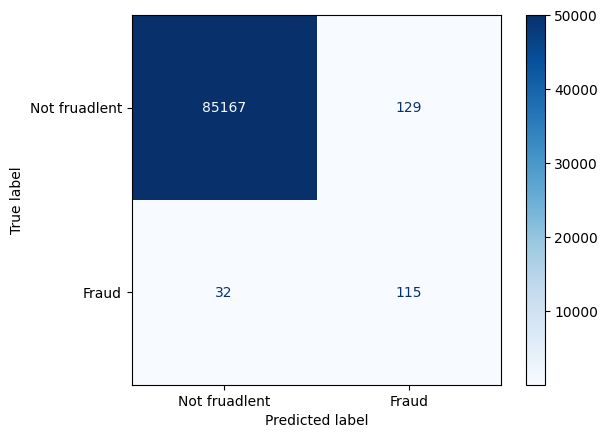

In [26]:
y_pred = classifier.predict(x_test)

# Evaluation of metrics
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay # Import RocCurveDisplay instead of plot_roc_curve

# Create the ConfusionMatrixDisplay
conf_matrix = confusion_matrix(y_test, y_pred.round())
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=['Not fruadlent','Fraud'])
disp.plot(cmap=plt.cm.Blues, values_format='d')
disp.im_.set_clim(vmax=50000)

# preformance metrics of model
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
print("Accuracy of the Decision tree:", acc)
print("Precision of the Decision tree:", prec)
print("Recall of the Decision tree:", rec)
print("F1 score of the Decision tree:", f1)

# Print the raw confusion matrix values
print("Confusion Matrix:")
print(conf_matrix)

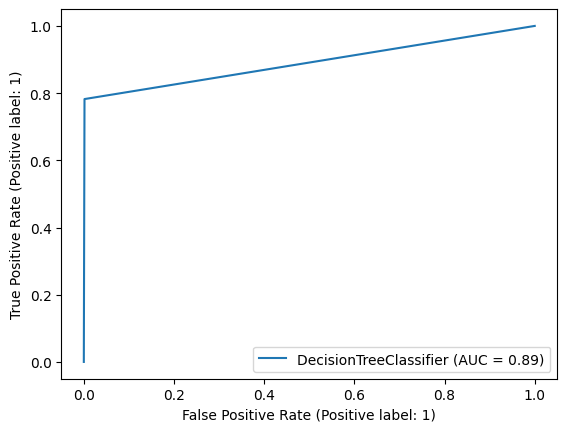

In [27]:
roc_display = RocCurveDisplay.from_estimator(classifier, x_test, y_test)
plt.show()

Confusion Matrix:
[[284186    129]
 [    32    460]]


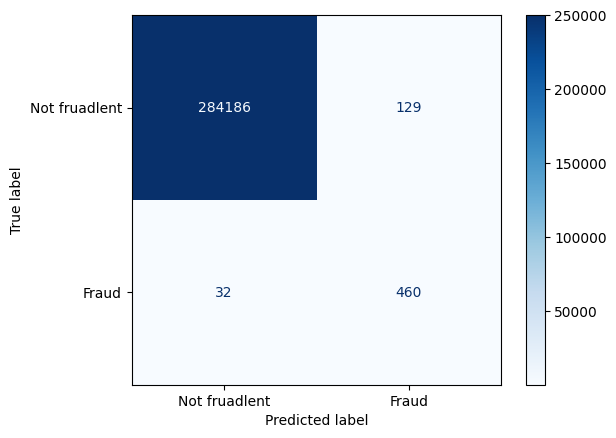

In [28]:
#confusion matrix for whole dataset
y_pred = classifier.predict(x)
conf_matrix = confusion_matrix(y, y_pred.round())
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=['Not fruadlent','Fraud'])
disp.plot(cmap=plt.cm.Blues, values_format='d')
disp.im_.set_clim(vmax=250000)

# Print the raw confusion matrix values
print("Confusion Matrix:")
print(conf_matrix)

plt.show()

# **DEEP NEURAL NETWORKS**

In [47]:
from keras.models import Sequential
from keras.layers import Dense
from keras.layers import Dropout

In [48]:
model = Sequential([
    Dense(units=16, input_dim = 29,activation='relu'),   # input of 29 columns as shown above
    Dense(units=24,activation='relu'),
    Dropout(0.5),
    Dense(20,activation='relu'),
    Dense(20,activation='relu'),
    Dense(1,activation='sigmoid'),                        # binary classification fraudulent or not
])

/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [49]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_5 (Dense)                      │ (None, 16)                  │             480 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 24)                  │             408 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 24)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 20)                  │             500 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ (None, 20)                  │             420 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_9 (Dense)                      │ (None, 1)                   │              21 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,829 (7.14 KB)

 Trainable params: 1,829 (7.14 KB)

 Non-trainable params: 0 (0.00 B)

In [50]:
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])
model.fit(x_train_resampled,y_train_resampled,batch_size=15,epochs=5)

Epoch 1/5
26536/26536 ━━━━━━━━━━━━━━━━━━━━ 64s 2ms/step - accuracy: 0.9693 - loss: 0.0761
Epoch 2/5
26536/26536 ━━━━━━━━━━━━━━━━━━━━ 61s 2ms/step - accuracy: 0.9971 - loss: 0.0113
Epoch 3/5
26536/26536 ━━━━━━━━━━━━━━━━━━━━ 64s 2ms/step - accuracy: 0.9979 - loss: 0.0091
Epoch 4/5
26536/26536 ━━━━━━━━━━━━━━━━━━━━ 83s 2ms/step - accuracy: 0.9982 - loss: 0.0082
Epoch 5/5
26536/26536 ━━━━━━━━━━━━━━━━━━━━ 80s 2ms/step - accuracy: 0.9984 - loss: 0.0072


In [51]:
score = model.evaluate(x_test,y_test)

2671/2671 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.9975 - loss: 0.0189


In [52]:
print(score)

[0.024073557928204536, 0.9975070953369141]


In [53]:
x_test = x_test.iloc[:, :29]

y_pred = model.predict(x_test)
y_test = pd.DataFrame(y_test)

2671/2671 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step


Accuracy for deep neural networks: 0.9975
Precision for deep neural networks: 0.3962
Recall for deep neural networks: 0.8571
F1 Score for deep neural networks: 0.5419
Confusion matrix, without normalization
[[85104   192]
 [   21   126]]


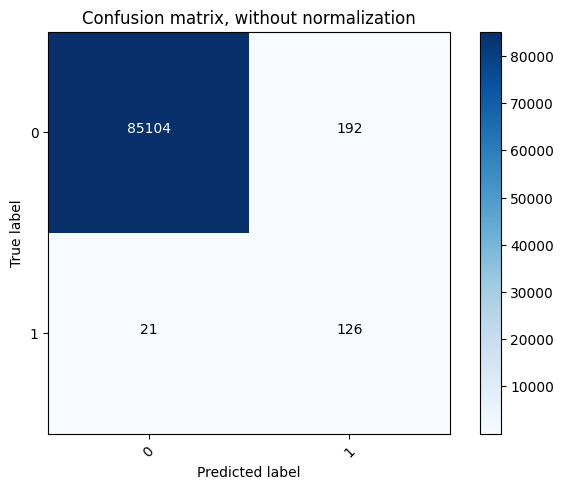

In [54]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, auc
import itertools

# Convert y_pred to binary predictions using a threshold
y_pred_binary = (y_pred > 0.5).astype(int)

# Calculate metrics
accuracy = accuracy_score(y_test, y_pred_binary)
precision = precision_score(y_test, y_pred_binary)
recall = recall_score(y_test, y_pred_binary)
f1 = f1_score(y_test, y_pred_binary)

print(f"Accuracy for deep neural networks: {accuracy:.4f}")
print(f"Precision for deep neural networks: {precision:.4f}")
print(f"Recall for deep neural networks: {recall:.4f}")
print(f"F1 Score for deep neural networks: {f1:.4f}")

# Plot confusion matrix
def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion Matrix',
                          cmap=plt.cm.Blues):
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized confusion matrix")
    else:
        print('Confusion matrix, without normalization')

    print(cm)
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)
    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred_binary)
class_names = [0, 1]
# Plot confusion matrix
plt.figure()
plot_confusion_matrix(cm, classes=class_names,
                      title='Confusion matrix, without normalization')

plt.show()

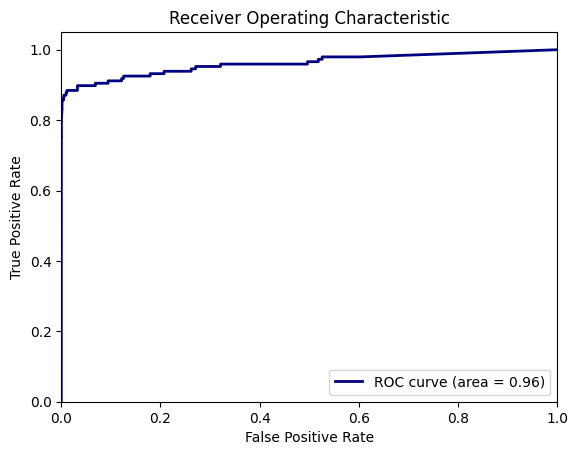

In [55]:
# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color='navy', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

In [56]:
y_pred = model.predict(x)
y_expected = pd.DataFrame(y)

8901/8901 ━━━━━━━━━━━━━━━━━━━━ 13s 1ms/step


Confusion matrix, without normalization
[[283761    554]
 [    22    470]]


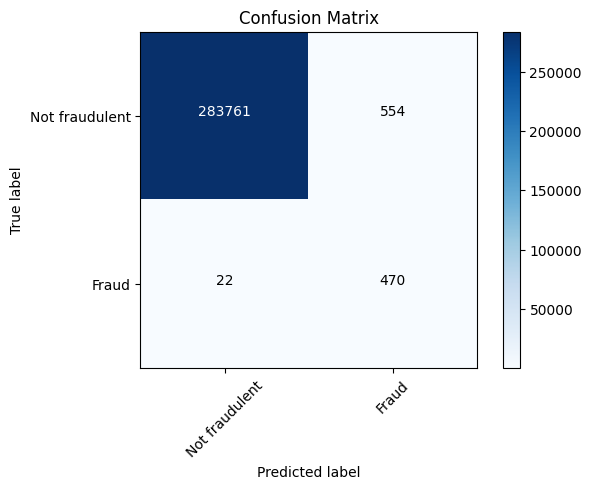

In [57]:
conf_matrix = confusion_matrix(y_expected, y_pred.round())
plot_confusion_matrix(conf_matrix, classes=['Not fraudulent', 'Fraud'])  # Corrected function name
plt.show()